<a href="https://colab.research.google.com/github/DikozWorld/Chisl-metods-labs/blob/main/lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- СРАВНИТЕЛЬНЫЙ АНАЛИЗ РАЗНОСТНЫХ СХЕМ ---
       x  Правая схема (O(h))  Центральная схема (O(h²))  Разность схем
0.000000             0.000000                   0.000000       0.000000
0.200000             0.244063                   0.212338       0.031724
0.400000             0.375901                   0.322170       0.053730
0.600000             0.379489                   0.320092       0.059397
0.800000             0.250681                   0.207767       0.042914
1.000000             0.000000                   0.000000       0.000000


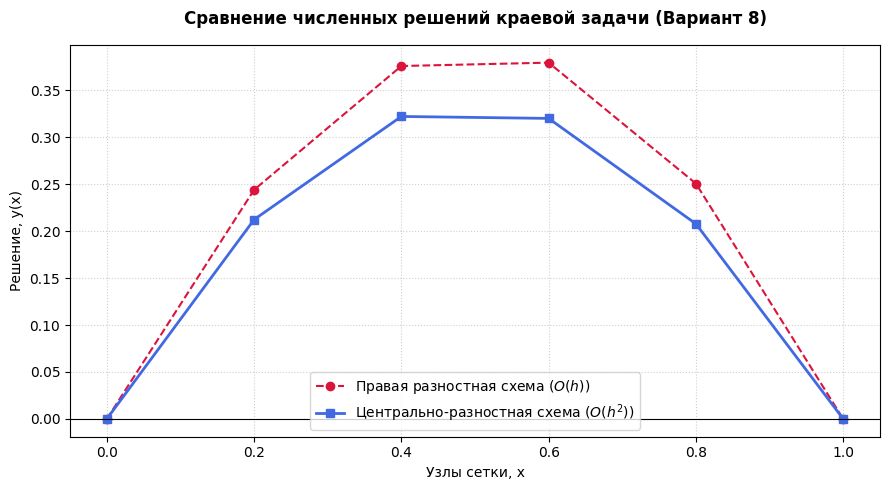

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. ИСХОДНЫЕ ДАННЫЕ (Вариант 8)
# Сетка точек x и табличные значения функции f5(x)
x = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
f5 = np.array([-1.4747, -1.4480, -1.4246, -1.4043, -1.3869, -1.3722])

h = 0.2          # Шаг сетки
N = len(x) - 1   # Количество интервалов (5)
a = 0.7 + 0.05 * 4  # Для k = 4 получаем a = 0.9

# Функции уравнения: y'' + f(x)y' + g(x)y = s(x)
g = np.cos(a * x)
s = 2 * (x**2) + 2 * x - 4

# Граничные условия: y(0) = 0, y(1) = 0
y0, yN = 0.0, 0.0

# 2. ФУНКЦИЯ МЕТОДА ПРОГОНКИ (Алгоритм Томаса)
def thomas_algorithm(A, C, B, F, y0, yN, N):
    alpha = np.zeros(N + 1)
    beta = np.zeros(N + 1)

    # Левое краевое условие: y_0 = y0
    alpha[1] = 0
    beta[1] = y0

    # Прямой ход прогонки
    for i in range(1, N):
        denom = C[i] + A[i] * alpha[i]
        alpha[i+1] = -B[i] / denom
        beta[i+1] = (F[i] - A[i] * beta[i]) / denom

    # Обратный ход прогонки
    y = np.zeros(N + 1)
    y[N] = yN
    for i in range(N - 1, -1, -1):
        y[i] = alpha[i+1] * y[i+1] + beta[i+1]

    return y

# 3. РАСЧЕТ ДВУМЯ СХЕМАМИ
# Схема А: Правая разностная схема (то, что было)
A_right = np.ones(N + 1)
C_right = -2 - h * f5 + (h**2) * g
B_right = 1 + h * f5
F_right = (h**2) * s
y_right = thomas_algorithm(A_right, C_right, B_right, F_right, y0, yN, N)

# Схема Б: Центрально-разностная схема (то, что ТРЕБУЕТ препод)
A_central = 1 - (h / 2.0) * f5
C_central = -2 + (h**2) * g
B_central = 1 + (h / 2.0) * f5
F_central = (h**2) * s
y_central = thomas_algorithm(A_central, C_central, B_central, F_central, y0, yN, N)

# 4. ВЫВОД РЕЗУЛЬТАТОВ И СРАВНЕНИЯ
df_compare = pd.DataFrame({
    'x': x,
    'Правая схема (O(h))': y_right,
    'Центральная схема (O(h²))': y_central,
    'Разность схем': np.abs(y_right - y_central)
})

print("--- СРАВНИТЕЛЬНЫЙ АНАЛИЗ РАЗНОСТНЫХ СХЕМ ---")
print(df_compare.to_string(index=False, float_format=lambda val: f"{val:.6f}"))

# 5. ПОСТРОЕНИЕ И ВИЗУАЛИЗАЦИЯ ГРАФИКОВ
plt.figure(figsize=(9, 5), dpi=100)
plt.plot(x, y_right, 'o--', color='crimson', label='Правая разностная схема ($O(h)$)', linewidth=1.5)
plt.plot(x, y_central, 's-', color='royalblue', label='Центрально-разностная схема ($O(h^2)$)', linewidth=2)

# Оформление графика
plt.title('Сравнение численных решений краевой задачи (Вариант 8)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Узлы сетки, x', fontsize=10)
plt.ylabel('Решение, y(x)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower center', fontsize=10)

# Выделение граничных условий
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.tight_layout()

# Сохранение графика в файл
plt.savefig('progonka_methods.png')
plt.show()